In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
N = 10
a = 2
L = N*a

eps = 1e-8
R = 1


# liczba indexów w 3D to N**3

positions = []

for i in range(N):
    for j in range(N):
        for k in range(N):
            positions.append([i*a, j*a, k*a])
            
positions = np.array(positions)
print(positions)

[[ 0  0  0]
 [ 0  0  2]
 [ 0  0  4]
 ...
 [18 18 14]
 [18 18 16]
 [18 18 18]]


In [58]:
#r jako wektor różnicy położeń 
#d jako dystans miedzy parą atomów
def pbc_delta(r1, r2, L):
    r = r1 - r2
    r = r - L * np.round(r/L)
    return r
def V(r1, r2):
    r = pbc_delta(r1, r2, L)
    d = np.sqrt(np.sum(r**2))
    V = eps*((R/d)**12 - 2*(R/d)**6)
    return V

def F(r1, r2):
    r = pbc_delta(r1, r2, L)
    d = np.sqrt(np.sum(r**2))
    F = 12*eps/d *((R/d)**12 - (R/d)**6)
    Fx = F * r[0]/d
    Fy = F * r[1]/d
    Fz = F * r[2]/d
    return [Fx, Fy, Fz]

In [59]:
print(pbc_delta(positions[0], positions[1], L))

[ 0.  0. -2.]


In [70]:
Energia_potencialna_ukladu = 0

for i in range(len(positions)):
    for j in range(1+i, len(positions)):
        Energia_potencialna_ukladu += V(positions[i], positions[j])
        
Forces = np.zeros((len(positions), 3))

for i in range(len(positions)):
    for j in range(1+i, len(positions)):
        F_ij = F(positions[i], positions[j])
        Forces[i] += F_ij
        Forces[j] -= F_ij
        
print(Forces)

[[ 2.84186123e-13  2.84186123e-13  2.84186123e-13]
 [ 2.84186123e-13  2.84186123e-13  2.84186123e-13]
 [ 2.84186123e-13  2.84186123e-13  2.84186123e-13]
 ...
 [-2.84186123e-13 -2.84186123e-13 -2.84186123e-13]
 [-2.84186123e-13 -2.84186123e-13 -2.84186123e-13]
 [-2.84186123e-13 -2.84186123e-13 -2.84186123e-13]]


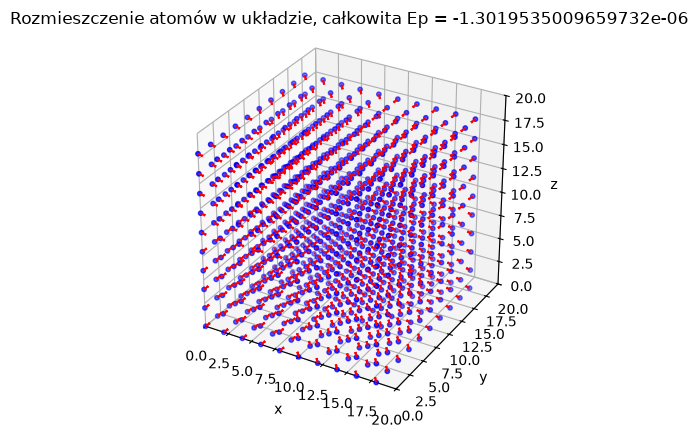

In [75]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(positions[:,0], positions[:,1],positions[:,2], s=10, c='blue')
ax.quiver(positions[:,0], positions[:,1], positions[:,2], Forces[:,0], Forces[:,1], Forces[:,2], length=1e12, color='red')
ax.set_title(f"Rozmieszczenie atomów w układzie, całkowita Ep = {Energia_potencialna_ukladu}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)

ax.set_box_aspect((1, 1, 1))

plt.show()